2.1. Постановка задачи


Выбранный набор данных CWRU Bearing Dataset предназначен для решения задачи классификации временных рядов — определения технического состояния подшипника качения на основе анализа вибрационных сигналов.

Формулировка задачи: необходимо по временному ряду виброускорений, зарегистрированному на корпусе подшипникового узла, отнести состояние подшипника к одному из заранее известных классов: нормальное состояние (Normal), неисправность внутреннего кольца (Inner Race, IR), неисправность тела качения (Ball, B), неисправность наружного кольца (Outer Race, OR). Для неисправности наружного кольца дополнительно различаются позиции: центрированная (OR@6), ортогональная (OR@3) и противоположная (OR@12).

Входные данные: одномерный временной ряд виброускорения (g), зарегистрированный акселерометром с частотой дискретизации 12 кГц или 48 кГц.

Выход модели: метка класса, соответствующая типу технического состояния подшипника.

Специфика задачи: ключевым признаком для классификации являются периодические ударные импульсы, возникающие при прохождении дефекта через зону контакта. Частота и форма этих импульсов зависят от типа и расположения дефекта, а также от частоты вращения вала.



2.2. Описание выбранного набора данных

Общая информация

Название: Case Western Reserve University (CWRU) Bearing Dataset

Источник: GitHub — srigas/CWRU_Bearing_NumPy

Оригинальный источник: Case School of Engineering, Case Western Reserve University


Лицензия: Academic (академическое использование, все права принадлежат CWRU)

Формат данных: .npz (NumPy compressed archive), конвертировано из оригинального .mat

Описание эксперимента

Данные получены на экспериментальном стенде с электродвигателем Reliance Electric мощностью 2 л.с. Дефекты подшипников (диаметром 0.007", 0.014", 0.021", 0.028") были искусственно созданы методом электроэрозионной обработки (EDM) на внутреннем кольце, теле качения и наружном кольце. Вибрационные сигналы регистрировались акселерометрами, установленными на приводном конце (DE), вентиляторном конце (FE) и основании (BA) двигателя при нагрузках от 0 до 3 л.с. (частоты вращения 1797–1730 об/мин).

Структура данных

Общее количество файлов: 48

Категории состояний:

Normal (нормальное состояние) — 4 файла (по одному на каждую скорость)

Inner Race (IR) — неисправность внутреннего кольца

Ball (B) — неисправность тела качения

Outer Race (OR) — неисправность наружного кольца (3 позиции: центрированная @6:00, ортогональная @3:00, противоположная @12:00)

Диаметры дефектов: 7, 14, 21, 28 милс (0.007"–0.028")

Частоты дискретизации: 12 кГц (DE12, FE) и 48 кГц (DE48)

Каналы: DE (Drive End), FE (Fan End), BA (Base)

Длительность записей: ~10 секунд (120 000 отсчётов при 12 кГц)

боснование выбора

Набор данных CWRU является одним из наиболее широко используемых бенчмарков в области диагностики подшипников. Его преимущества:

Эталонное качество данных — сигналы записаны в контролируемых лабораторных условиях.

Полная размеченность — каждому файлу соответствует известный тип неисправности.

Вариативность — различные типы, размеры и расположения дефектов позволяют обучить модель различать тонкие паттерны.

2.3. Описание результатов первичного анализа

In [1]:
# ЭТАП 1: ЗАГРУЗКА И ПЕРВИЧНОЕ ЗНАКОМСТВО С ДАННЫМИ

# 1.1. Подключение Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 1.2. Клонирование репозитория
!git clone https://github.com/srigas/CWRU_Bearing_NumPy.git /content/cwru_bearing_data 2>/dev/null || echo "Репозиторий уже клонирован"

# Проверим структуру папок
!ls /content/cwru_bearing_data/
!ls /content/cwru_bearing_data/Data/

# 1.3. Импорт всех необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('ggplot')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Все библиотеки успешно импортированы.")

Mounted at /content/drive
Contents.md  Data  README.md
'1730 RPM'  '1750 RPM'	'1772 RPM'  '1797 RPM'
Все библиотеки успешно импортированы.


In [2]:
# 1.4. Изучение структуры датасета
data_root = Path('/content/cwru_bearing_data/Data')
rpm_folders = sorted([d for d in data_root.iterdir() if d.is_dir()])

print("=" * 70)
print("СТРУКТУРА ДАТАСЕТА CWRU BEARING")
print("=" * 70)

total_files = 0
for rpm_folder in rpm_folders:
    files = sorted(rpm_folder.glob('*.npz'))
    total_files += len(files)
    normal = [f for f in files if 'Normal' in f.name]
    ir = [f for f in files if '_IR_' in f.name]
    b = [f for f in files if '_B_' in f.name]
    or_files = [f for f in files if '_OR' in f.name]
    print(f"\n{rpm_folder.name}/ ({len(files)} файлов):")
    print(f"   Normal: {len(normal)} | IR: {len(ir)} | B: {len(b)} | OR: {len(or_files)}")
    for f in files[:3]:
        print(f"     • {f.name}")

print(f"\n{'=' * 70}")
print(f"ВСЕГО ФАЙЛОВ: {total_files}")

print("""
1. Датасет содержит несколько классов технических состояний подшипников:
   - Normal,
   - Inner Race (IR),
   - Ball (B),
   - Outer Race (OR).

2. Данные представлены многоканальными временными рядами виброускорений:
   - DE — приводной конец,
   - FE — вентиляторный конец,
   - BA — основание двигателя.

3. Наличие различных размеров и типов дефектов делает набор данных пригодным
   для обучения моделей классификации технических состояний.
""")

СТРУКТУРА ДАТАСЕТА CWRU BEARING

1730 RPM/ (40 файлов):
   Normal: 1 | IR: 10 | B: 10 | OR: 19
     • 1730_B_14_DE12.npz
     • 1730_B_14_DE48.npz
     • 1730_B_14_FE.npz

1750 RPM/ (40 файлов):
   Normal: 1 | IR: 10 | B: 10 | OR: 19
     • 1750_B_14_DE12.npz
     • 1750_B_14_DE48.npz
     • 1750_B_14_FE.npz

1772 RPM/ (40 файлов):
   Normal: 1 | IR: 10 | B: 10 | OR: 19
     • 1772_B_14_DE12.npz
     • 1772_B_14_DE48.npz
     • 1772_B_14_FE.npz

1797 RPM/ (41 файлов):
   Normal: 1 | IR: 10 | B: 10 | OR: 20
     • 1797_B_14_DE12.npz
     • 1797_B_14_DE48.npz
     • 1797_B_14_FE.npz

ВСЕГО ФАЙЛОВ: 161

1. Датасет содержит несколько классов технических состояний подшипников:
   - Normal,
   - Inner Race (IR),
   - Ball (B),
   - Outer Race (OR).

2. Данные представлены многоканальными временными рядами виброускорений:
   - DE — приводной конец,
   - FE — вентиляторный конец,
   - BA — основание двигателя.

3. Наличие различных размеров и типов дефектов делает набор данных пригодным
   для

In [3]:
# 1.5. Загрузка примера и анализ структуры .npz файла
# ВАЖНО: форма массивов — (N, 1), поэтому используем .flatten()

example_dir = data_root / '1797 RPM'

# Нормальное состояние
normal_file = example_dir / '1797_Normal.npz'
data_normal_raw = np.load(normal_file)
# Конвертируем (N,1) → (N,)
data_normal = {key: data_normal_raw[key].flatten() for key in data_normal_raw.keys()}

print(f"{normal_file.name}")
for key, arr in data_normal.items():
    print(f"   '{key}': shape={arr.shape}, dtype={arr.dtype}, "
          f"range=[{arr.min():.4f}, {arr.max():.4f}]")

# Неисправность IR
fault_file = example_dir / '1797_IR_7_DE12.npz'
data_fault_raw = np.load(fault_file)
data_fault = {key: data_fault_raw[key].flatten() for key in data_fault_raw.keys()}

print(f"\n{fault_file.name}")
for key, arr in data_fault.items():
    print(f"   '{key}': shape={arr.shape}, dtype={arr.dtype}, "
          f"range=[{arr.min():.4f}, {arr.max():.4f}]")

# Неисправность OR
or_file = example_dir / '1797_OR@6_7_DE12.npz'
data_or_raw = np.load(or_file)
data_or = {key: data_or_raw[key].flatten() for key in data_or_raw.keys()}

print(f"\n{or_file.name}")
for key, arr in data_or.items():
    print(f"   '{key}': shape={arr.shape}, dtype={arr.dtype}, "
          f"range=[{arr.min():.4f}, {arr.max():.4f}]")

1797_Normal.npz
   'DE': shape=(243938,), dtype=float64, range=[-0.2866, 0.3113]
   'FE': shape=(243938,), dtype=float64, range=[-0.2461, 0.3575]

1797_IR_7_DE12.npz
   'DE': shape=(121265,), dtype=float64, range=[-1.3799, 1.7390]
   'FE': shape=(121265,), dtype=float64, range=[-1.1397, 0.9632]
   'BA': shape=(121265,), dtype=float64, range=[-0.3491, 0.3720]

1797_OR@6_7_DE12.npz
   'DE': shape=(121991,), dtype=float64, range=[-3.4087, 3.6304]
   'FE': shape=(121991,), dtype=float64, range=[-1.0351, 1.1053]
   'BA': shape=(121991,), dtype=float64, range=[-0.3516, 0.3951]


In [4]:
# 1.6. Создание полного каталога с метаданными
def parse_cwru_filename(filepath):
    """Парсит имя файла CWRU."""
    name = filepath.stem
    parts = name.split('_')
    rpm = int(parts[0])

    if 'Normal' in name:
        return {'rpm': rpm, 'fault_type': 'Normal', 'diameter_mils': 0,
                'end': 'N/A', 'sampling_rate_khz': None, 'full_path': str(filepath)}

    fault_type = parts[1]
    diameter = None
    end = None
    sr = None

    for part in parts[2:]:
        if part in {'7', '14', '21', '28'}:
            diameter = int(part)
        elif part in {'DE12', 'DE48', 'FE'}:
            end = part
            sr = 48 if '48' in part else 12

    return {'rpm': rpm, 'fault_type': fault_type,
            'diameter_mils': diameter if diameter else 0,
            'end': end if end else 'Unknown',
            'sampling_rate_khz': sr, 'full_path': str(filepath)}

all_records = []
for rpm_folder in rpm_folders:
    for npz_file in rpm_folder.glob('*.npz'):
        all_records.append(parse_cwru_filename(npz_file))

df_catalog = pd.DataFrame(all_records)
print(f"Каталог создан: {len(df_catalog)} записей")
df_catalog.head(10)

Каталог создан: 161 записей


,rpm,fault_type,diameter_mils,end,sampling_rate_khz,full_path
0,1730,OR@3,7,FE,12.0,/content/cwru_bearing_data/Data/1730 RPM/1730_...
1,1730,B,14,DE48,48.0,/content/cwru_bearing_data/Data/1730 RPM/1730_...
2,1730,B,21,DE48,48.0,/content/cwru_bearing_data/Data/1730 RPM/1730_...
3,1730,OR@12,7,DE12,12.0,/content/cwru_bearing_data/Data/1730 RPM/1730_...
4,1730,IR,21,DE12,12.0,/content/cwru_bearing_data/Data/1730 RPM/1730_...
5,1730,IR,21,FE,12.0,/content/cwru_bearing_data/Data/1730 RPM/1730_...
6,1730,Normal,0,N/A,NaN,/content/cwru_bearing_data/Data/1730 RPM/1730_...
7,1730,OR@3,21,DE48,48.0,/content/cwru_bearing_data/Data/1730 RPM/1730_...
8,1730,B,7,DE12,12.0,/content/cwru_bearing_data/Data/1730 RPM/1730_...
9,1730,IR,14,DE12,12.0,/content/cwru_bearing_data/Data/1730 RPM/1730_...


In [5]:
# 1.7. Сводная статистика (для отчёта)
print("=" * 60)
print("СВОДНАЯ СТАТИСТИКА ДАТАСЕТА")
print("=" * 60)
print("\nПо RPM:")
print(df_catalog['rpm'].value_counts().sort_index())
print("\nПо типам состояний:")
print(df_catalog['fault_type'].value_counts())
print("\nПо диаметрам дефектов:")
print(df_catalog['diameter_mils'].value_counts().sort_index())
print("\nПо датчикам (end):")
print(df_catalog['end'].value_counts())

СВОДНАЯ СТАТИСТИКА ДАТАСЕТА

По RPM:
rpm
1730    40
1750    40
1772    40
1797    41
Name: count, dtype: int64

По типам состояний:
fault_type
B         40
IR        40
OR@6      30
OR@3      27
OR@12     20
Normal     4
Name: count, dtype: int64

По диаметрам дефектов:
diameter_mils
0      4
7     60
14    37
21    52
28     8
Name: count, dtype: int64

По датчикам (end):
end
DE12    60
DE48    52
FE      45
N/A      4
Name: count, dtype: int64


2.3.2. Визуализация исходных данных

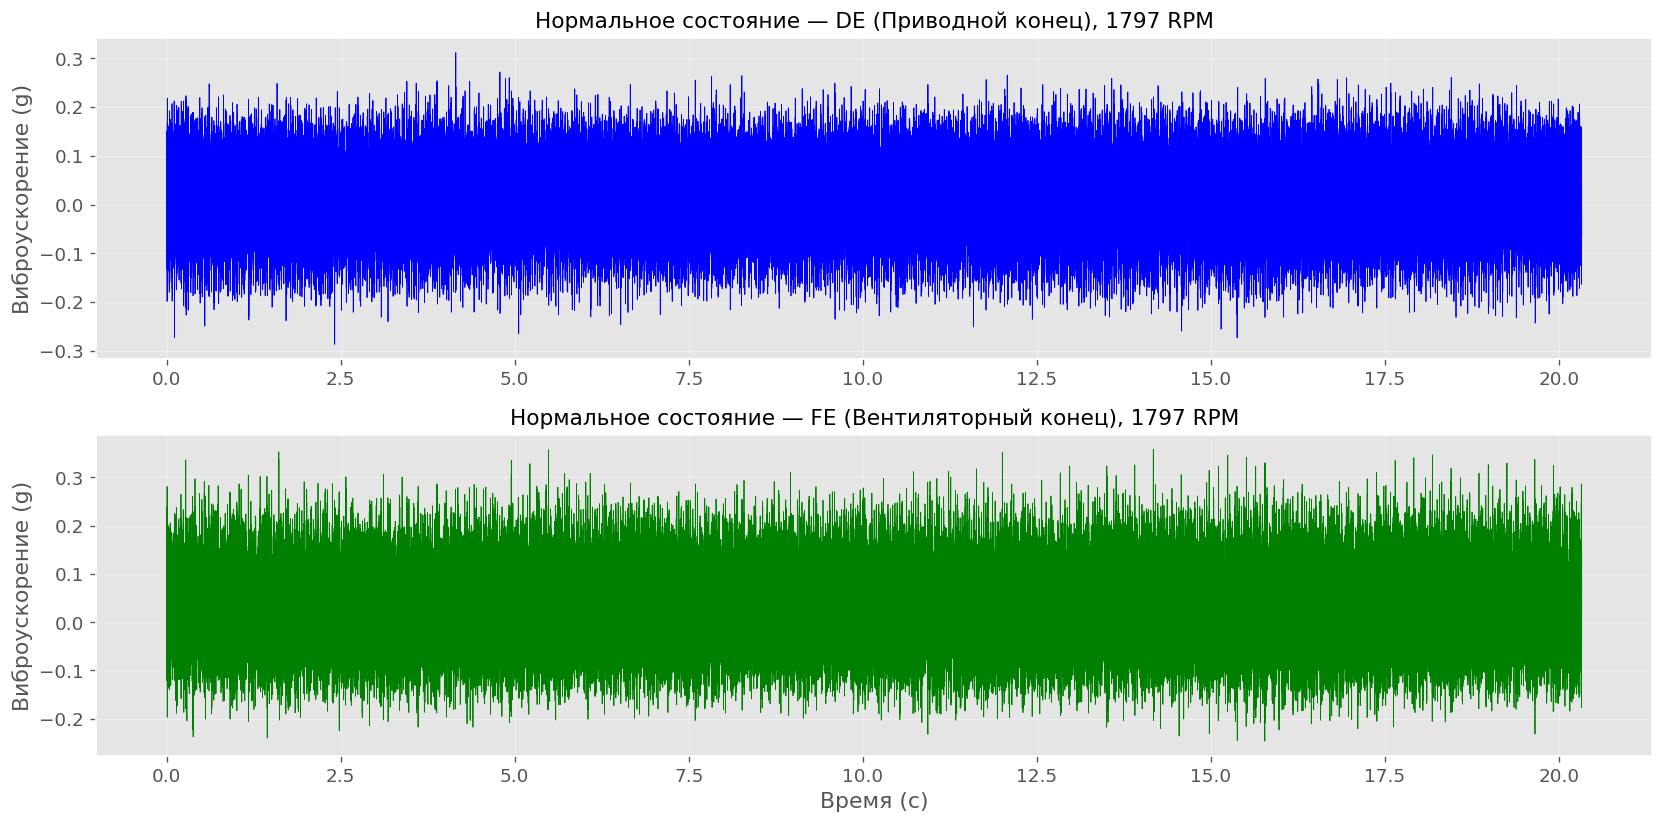

In [6]:
# ЭТАП 2: ВИЗУАЛИЗАЦИЯ ИСХОДНЫХ ДАННЫХ


sampling_rate_de12 = 12000  # Гц

# 2.1. Все каналы нормального состояния
time_normal = np.arange(len(data_normal['DE'])) / sampling_rate_de12

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(time_normal, data_normal['DE'], linewidth=0.5, color='blue')
axes[0].set_title('Нормальное состояние — DE (Приводной конец), 1797 RPM', fontsize=13)
axes[0].set_ylabel('Виброускорение (g)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_normal, data_normal['FE'], linewidth=0.5, color='green')
axes[1].set_title('Нормальное состояние — FE (Вентиляторный конец), 1797 RPM', fontsize=13)
axes[1].set_xlabel('Время (с)')
axes[1].set_ylabel('Виброускорение (g)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/normal_state.png', dpi=150, bbox_inches='tight')
plt.show()

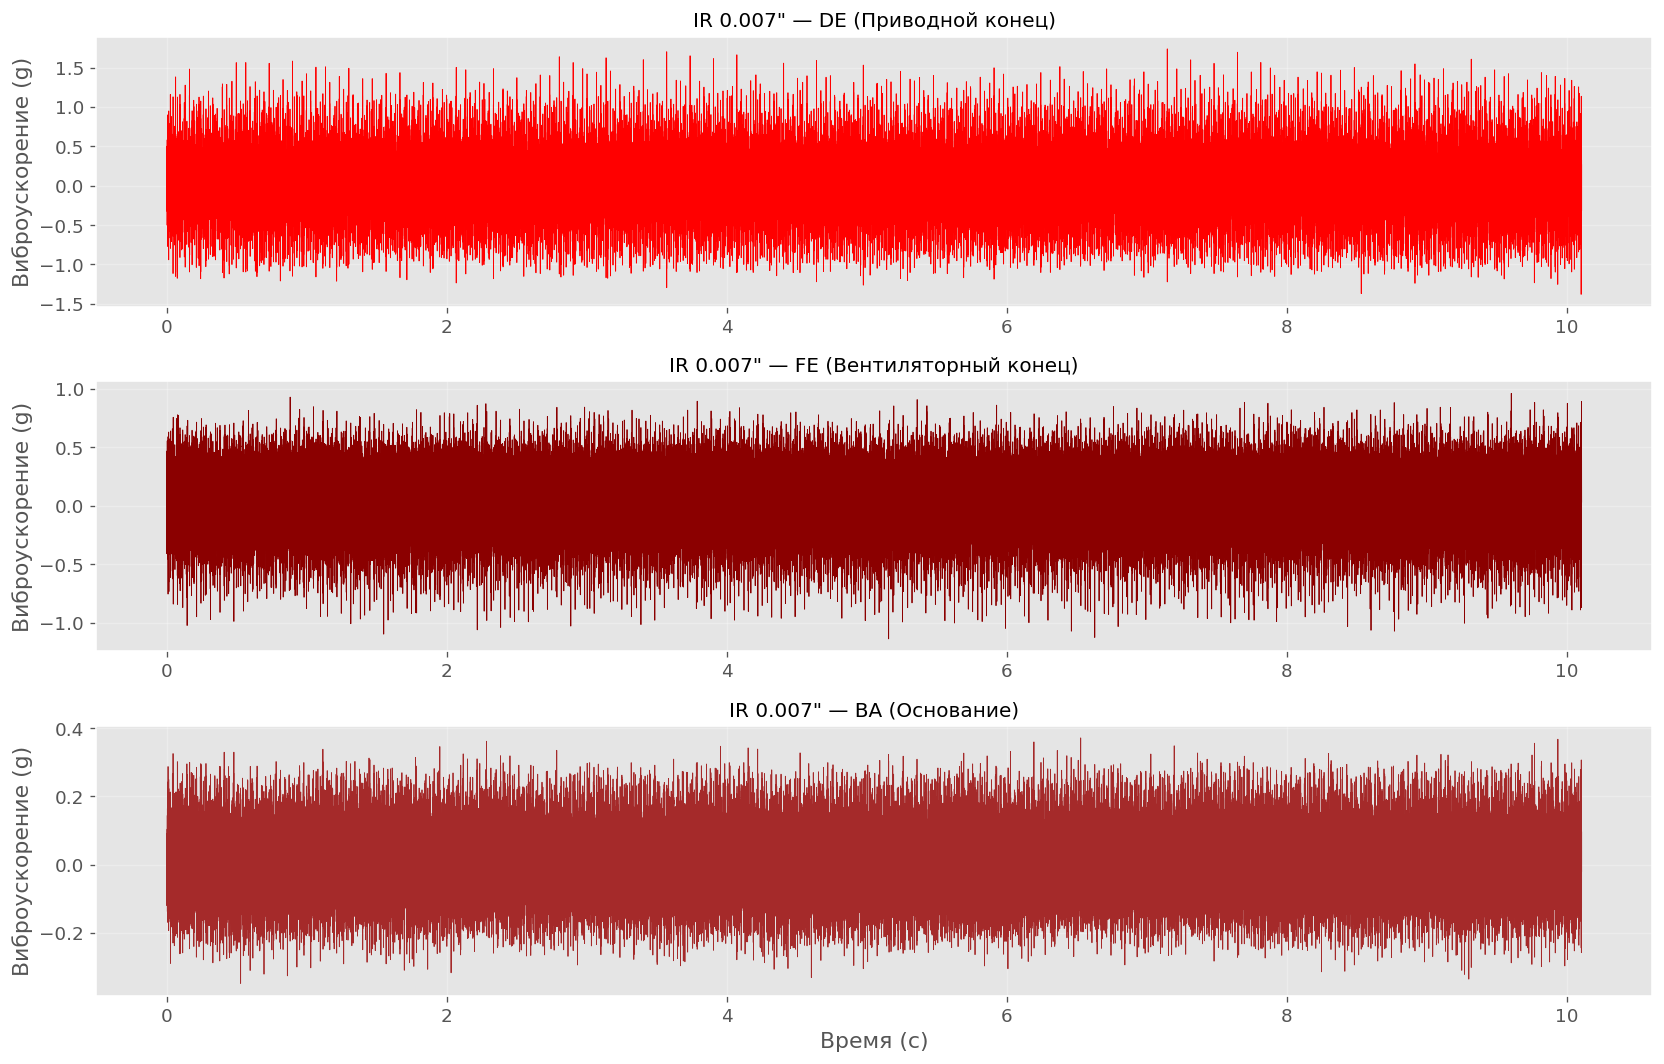

In [7]:
# 2.2. Все каналы неисправного состояния IR
time_fault = np.arange(len(data_fault['DE'])) / sampling_rate_de12

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
axes[0].plot(time_fault, data_fault['DE'], linewidth=0.5, color='red')
axes[0].set_title('IR 0.007" — DE (Приводной конец)', fontsize=12)
axes[0].set_ylabel('Виброускорение (g)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_fault, data_fault['FE'], linewidth=0.5, color='darkred')
axes[1].set_title('IR 0.007" — FE (Вентиляторный конец)', fontsize=12)
axes[1].set_ylabel('Виброускорение (g)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_fault, data_fault['BA'], linewidth=0.5, color='brown')
axes[2].set_title('IR 0.007" — BA (Основание)', fontsize=12)
axes[2].set_xlabel('Время (с)')
axes[2].set_ylabel('Виброускорение (g)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/fault_ir_channels.png', dpi=150, bbox_inches='tight')
plt.show()

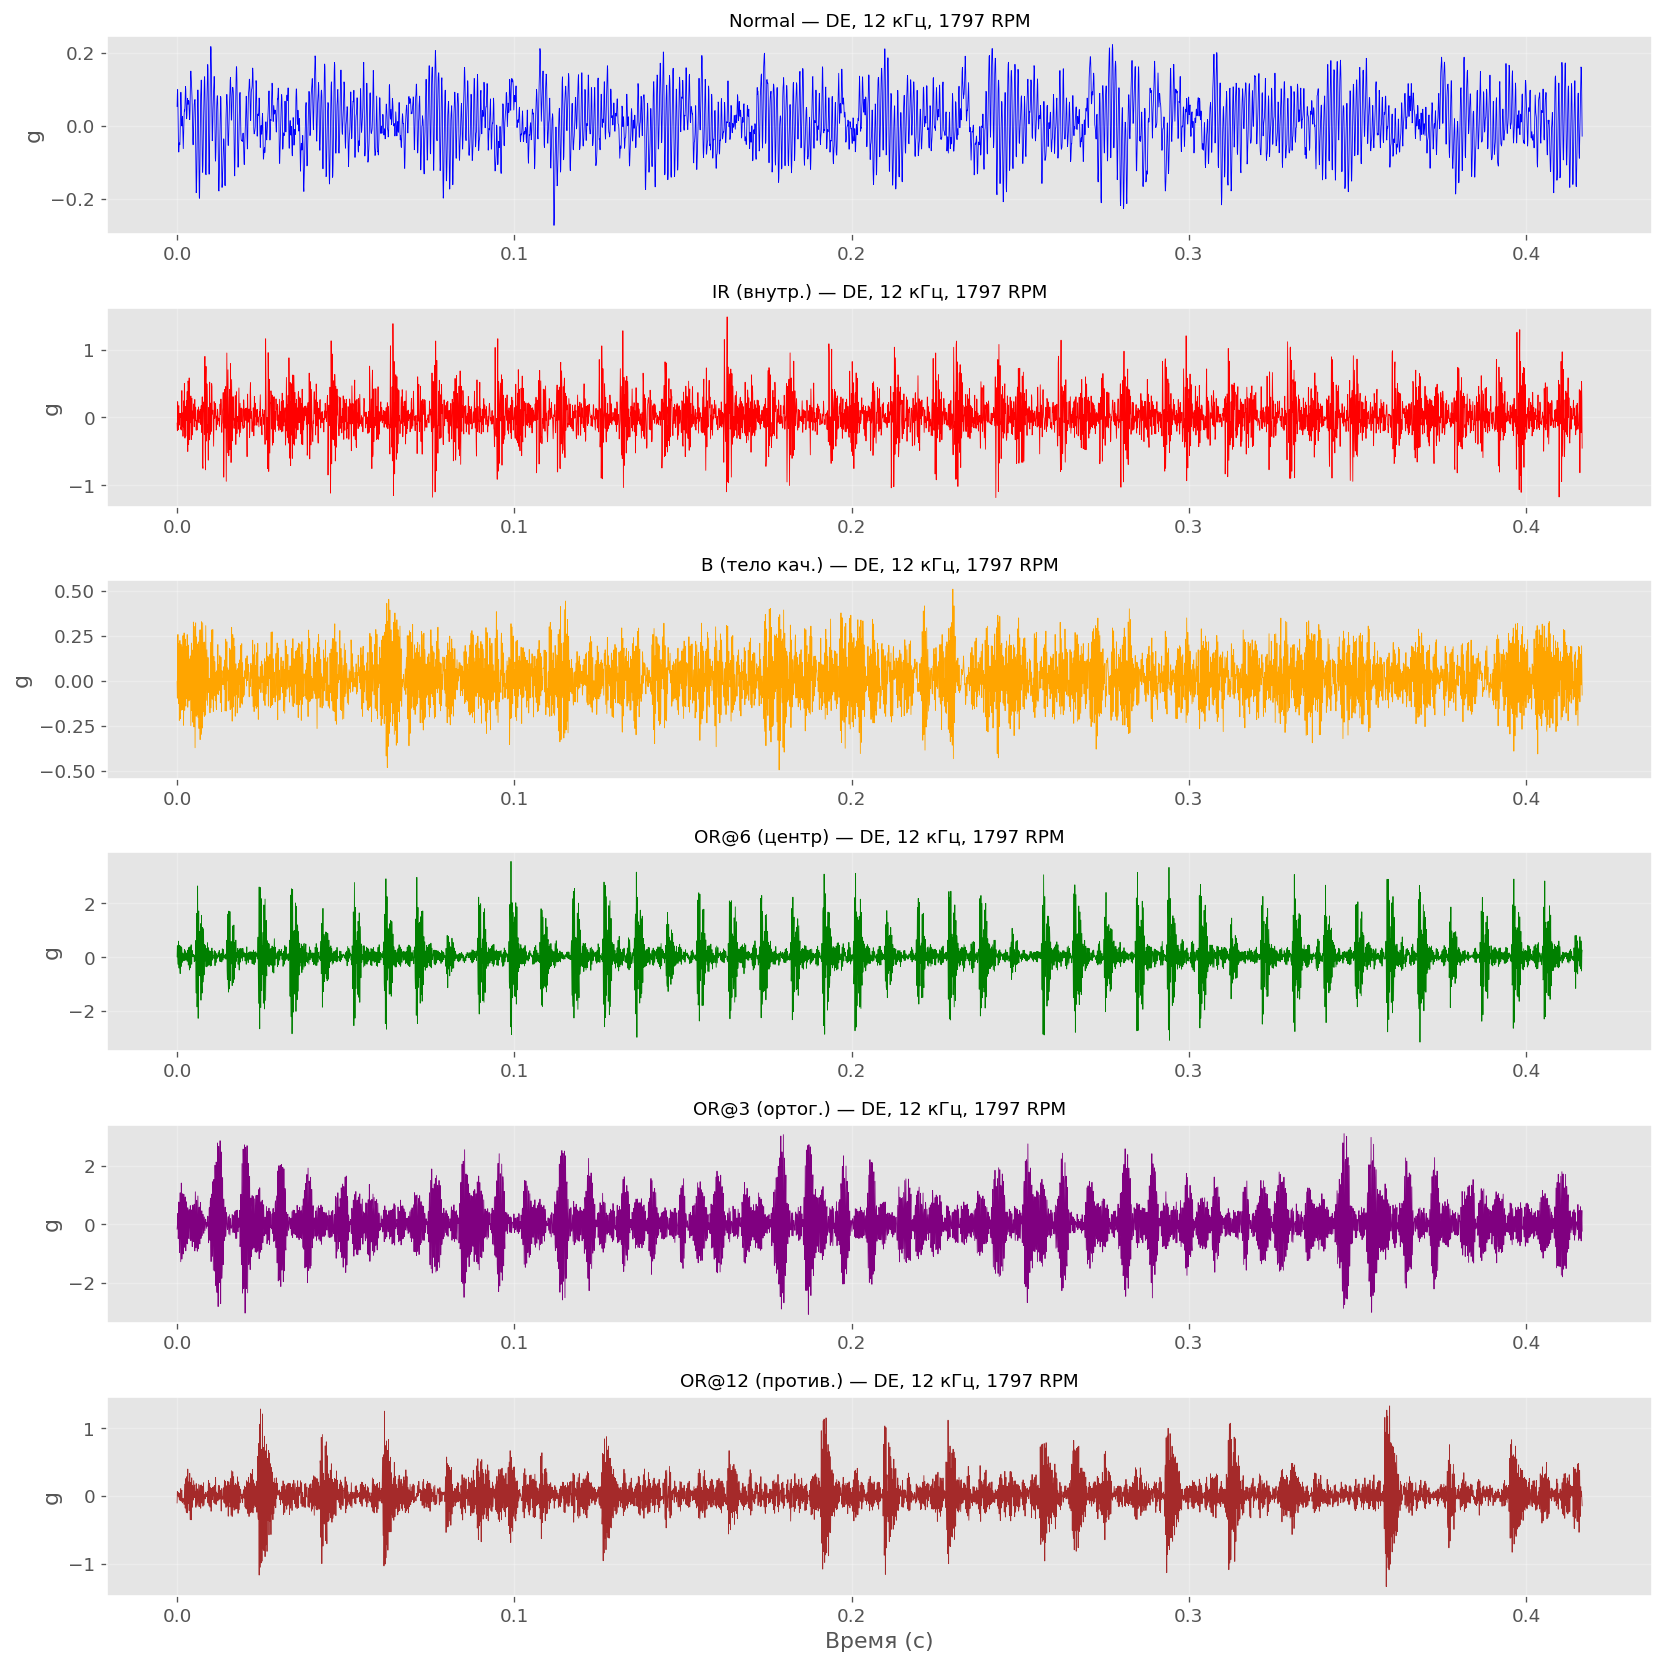

In [8]:
# 2.3. Сравнение всех 6 классов (DE12, 1797 RPM, диаметр 7 милс)
class_specs = {
    'Normal':     '1797_Normal.npz',
    'IR (внутр.)': '1797_IR_7_DE12.npz',
    'B (тело кач.)': '1797_B_7_DE12.npz',
    'OR@6 (центр)': '1797_OR@6_7_DE12.npz',
    'OR@3 (ортог.)': '1797_OR@3_7_DE12.npz',
    'OR@12 (против.)': '1797_OR@12_7_DE12.npz',
}

fig, axes = plt.subplots(len(class_specs), 1, figsize=(14, 14))
colors = ['blue', 'red', 'orange', 'green', 'purple', 'brown']

for i, (label, fname) in enumerate(class_specs.items()):
    fp = data_root / '1797 RPM' / fname
    if fp.exists():
        arr = np.load(fp)['DE'].flatten()
        t = np.arange(min(5000, len(arr))) / 12000
        axes[i].plot(t, arr[:5000], linewidth=0.5, color=colors[i])
        axes[i].set_title(f'{label} — DE, 12 кГц, 1797 RPM', fontsize=11)
        axes[i].set_ylabel('g')
        axes[i].grid(True, alpha=0.3)
    else:
        axes[i].text(0.5, 0.5, f'Файл не найден:\n{fname}', ha='center', va='center',
                     transform=axes[i].transAxes, fontsize=12, color='gray')

axes[-1].set_xlabel('Время (с)')
plt.tight_layout()
plt.savefig('/content/all_6_classes.png', dpi=150, bbox_inches='tight')
plt.show()

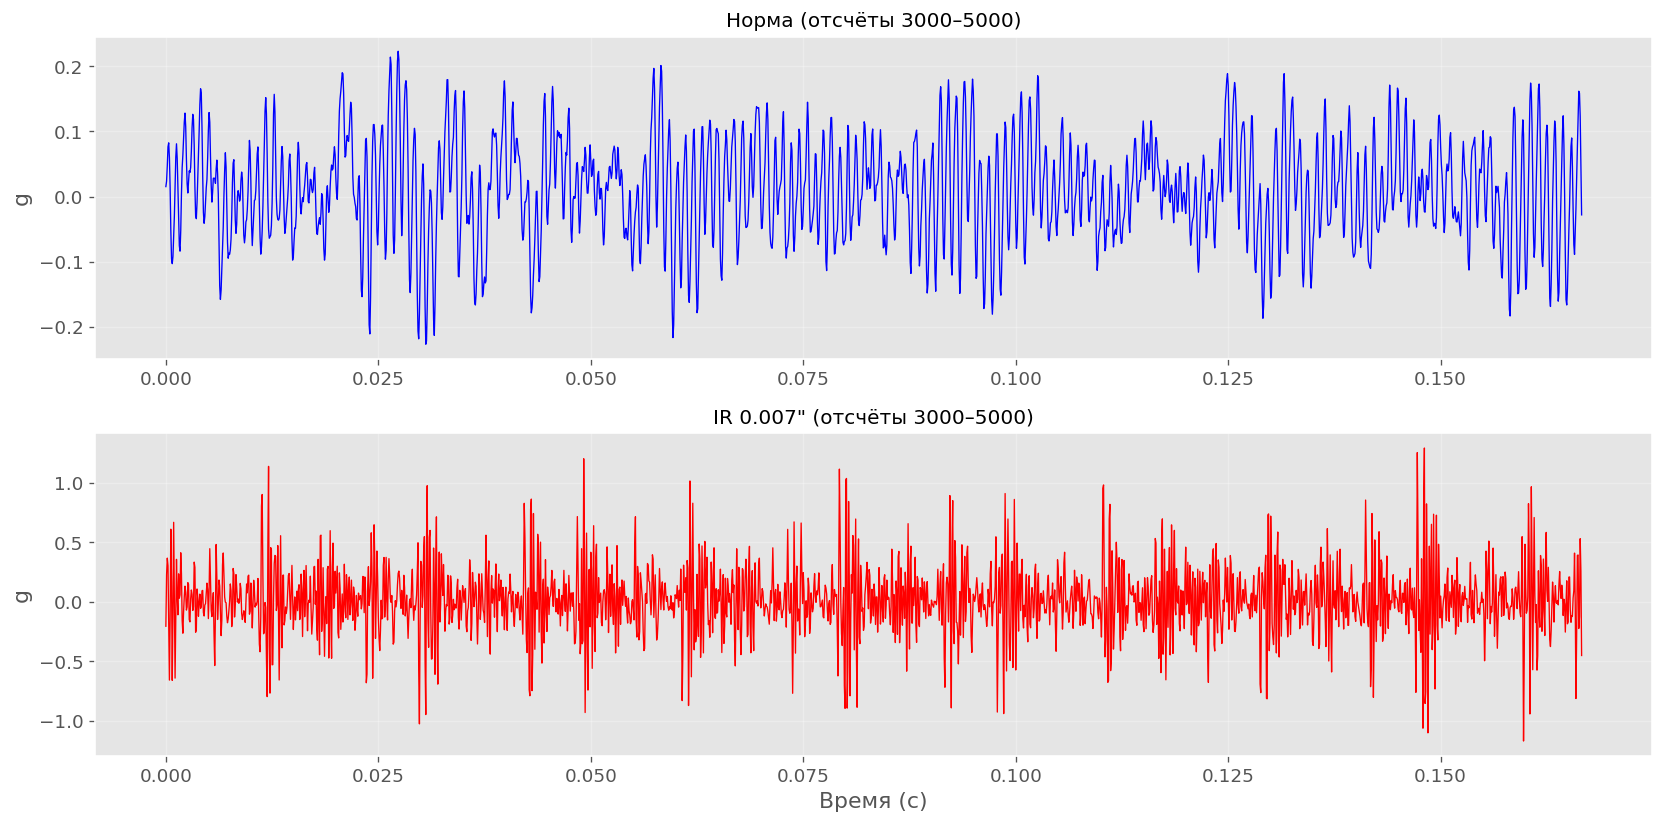


1. Вибрационные сигналы различных состояний подшипников
   визуально отличаются по форме и амплитуде.

2. Для неисправных состояний наблюдаются выраженные ударные импульсы
   и периодические всплески вибрации.

3. Нормальное состояние характеризуется более стабильным
   и менее импульсным сигналом.

4. Наиболее выраженные диагностические особенности
   наблюдаются в канале DE.

5. Временные ряды содержат характерные паттерны,
   пригодные для дальнейшего автоматического распознавания.



In [9]:
# 2.4. Увеличенный фрагмент: норма vs неисправность
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
start, end = 3000, 5000
t_zoom = np.arange(end - start) / 12000

axes[0].plot(t_zoom, data_normal['DE'][start:end], linewidth=0.8, color='blue')
axes[0].set_title(f'Норма (отсчёты {start}–{end})', fontsize=12)
axes[0].set_ylabel('g')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_zoom, data_fault['DE'][start:end], linewidth=0.8, color='red')
axes[1].set_title(f'IR 0.007" (отсчёты {start}–{end})', fontsize=12)
axes[1].set_xlabel('Время (с)')
axes[1].set_ylabel('g')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/zoom_normal_vs_fault.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
1. Вибрационные сигналы различных состояний подшипников
   визуально отличаются по форме и амплитуде.

2. Для неисправных состояний наблюдаются выраженные ударные импульсы
   и периодические всплески вибрации.

3. Нормальное состояние характеризуется более стабильным
   и менее импульсным сигналом.

4. Наиболее выраженные диагностические особенности
   наблюдаются в канале DE.

5. Временные ряды содержат характерные паттерны,
   пригодные для дальнейшего автоматического распознавания.
""")

2.3.3. Статистический анализ


In [10]:
# ЭТАП 3: СТАТИСТИЧЕСКИЙ АНАЛИЗ

# 3.1. Расчёт описательных статистик для всех классов (DE, 1797 RPM, диаметр 7)
stats_specs = {
    'Normal':     '1797_Normal.npz',
    'IR':         '1797_IR_7_DE12.npz',
    'B':          '1797_B_7_DE12.npz',
    'OR@6':       '1797_OR@6_7_DE12.npz',
    'OR@3':       '1797_OR@3_7_DE12.npz',
    'OR@12':      '1797_OR@12_7_DE12.npz',
}

stats_records = []
for label, fname in stats_specs.items():
    fp = data_root / '1797 RPM' / fname
    if fp.exists():
        sig = np.load(fp)['DE'].flatten()
        stats_records.append({
            'Класс': label,
            'N': len(sig),
            'Среднее': np.mean(sig),
            'СКО': np.std(sig),
            'Мин': np.min(sig),
            'Q1': np.quantile(sig, 0.25),
            'Медиана': np.median(sig),
            'Q3': np.quantile(sig, 0.75),
            'Макс': np.max(sig),
            'Размах': np.max(sig) - np.min(sig),
            'Асимметрия': stats.skew(sig),
            'Эксцесс': stats.kurtosis(sig)
        })

stats_df = pd.DataFrame(stats_records).set_index('Класс')
stats_df.round(4)

,N,Среднее,СКО,Мин,Q1,Медиана,Q3,Макс,Размах,Асимметрия,Эксцесс
Класс,,,,,,,,,,,
Normal,243938,0.0126,0.0727,-0.2866,-0.0376,0.0125,0.0636,0.3113,0.5979,-0.0354,-0.2358
IR,121265,0.0134,0.2912,-1.3799,-0.1351,0.0071,0.1602,1.7390,3.1189,0.1640,2.3959
B,122571,0.0126,0.1387,-0.6070,-0.0807,0.0128,0.1064,0.6039,1.2110,-0.0089,-0.0153
OR@6,121991,0.0232,0.6691,-3.4087,-0.1791,0.0219,0.2233,3.6304,7.0391,0.0569,4.6494
OR@3,122281,0.0072,0.7694,-3.2601,-0.4211,0.0008,0.4288,3.3490,6.6091,0.0658,1.2393
OR@12,122281,0.0111,0.2370,-1.7627,-0.1041,0.0102,0.1244,1.6909,3.4537,-0.0375,5.0535


In [11]:
# 3.2. Частота дискретизации и равномерность
print("=== ПАРАМЕТРЫ ДИСКРЕТИЗАЦИИ ===")
print(f"DE12/FE: 12 000 Гц → шаг {1/12000*1000:.4f} мс")
print(f"DE48:    48 000 Гц → шаг {1/48000*1000:.4f} мс")

# Проверка равномерности
diffs = np.diff(np.arange(len(data_fault['DE'])) / 12000)
print(f"Равномерность интервалов DE12: {'Да' if np.allclose(diffs, 1/12000) else 'Нет'}")

# Длительности
print(f"\nДлительность DE12 (Normal): {len(data_normal['DE'])/12000:.2f} с")
print(f"Длительность DE12 (IR):     {len(data_fault['DE'])/12000:.2f} с")

=== ПАРАМЕТРЫ ДИСКРЕТИЗАЦИИ ===
DE12/FE: 12 000 Гц → шаг 0.0833 мс
DE48:    48 000 Гц → шаг 0.0208 мс
Равномерность интервалов DE12: Да

Длительность DE12 (Normal): 20.33 с
Длительность DE12 (IR):     10.11 с


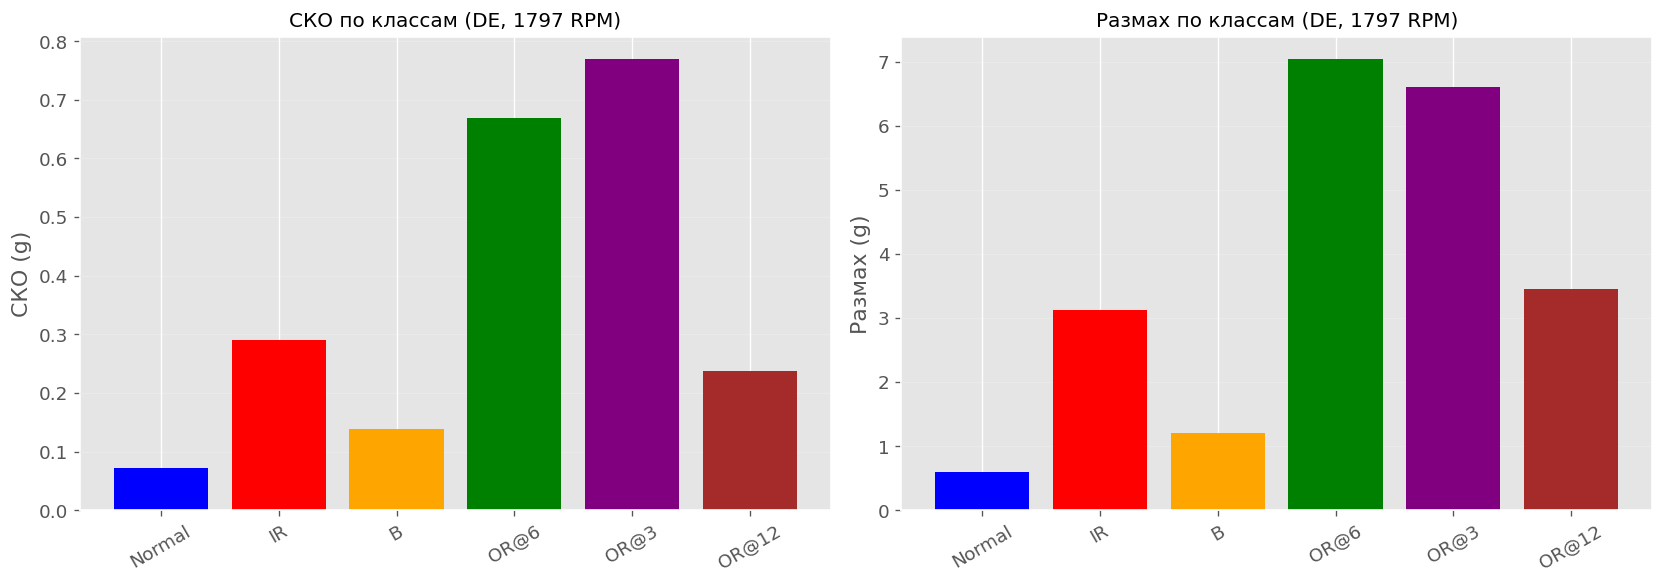

In [12]:
# 3.3. График сравнения СКО и Размаха по классам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(stats_df.index, stats_df['СКО'], color=['blue','red','orange','green','purple','brown'])
axes[0].set_title('СКО по классам (DE, 1797 RPM)', fontsize=12)
axes[0].set_ylabel('СКО (g)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.2, axis='y')

axes[1].bar(stats_df.index, stats_df['Размах'], color=['blue','red','orange','green','purple','brown'])
axes[1].set_title('Размах по классам (DE, 1797 RPM)', fontsize=12)
axes[1].set_ylabel('Размах (g)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('/content/stats_std_range.png', dpi=150, bbox_inches='tight')
plt.show()

2.3.4. Анализ пропусков и выбросов

In [13]:
# ЭТАП 4: АНАЛИЗ ПРОПУСКОВ И ВЫБРОСОВ

In [14]:
# 4.1. Проверка всех файлов на NaN
print("=== ПРОВЕРКА НА ПРОПУСКИ (NaN) ===")

nan_report = []
total_checked = 0

for _, row in df_catalog.iterrows():
    data = np.load(row['full_path'])
    for key in data.keys():
        total_checked += 1
        nc = np.isnan(data[key]).sum()
        if nc > 0:
            nan_report.append({
                'Файл': row['filename'] if 'filename' in row else Path(row['full_path']).name,
                'Канал': key,
                'Кол-во NaN': nc,
                'Доля (%)': round(nc / data[key].size * 100, 4)
            })

print(f"Проверено массивов: {total_checked}")
print(f"Файлов с NaN: {len(nan_report)}")

if nan_report:
    nan_df = pd.DataFrame(nan_report)
    print("\nНайдены пропуски:")
    print(nan_df.to_string(index=False))
else:
    print("Пропущенных значений (NaN) не обнаружено.")

=== ПРОВЕРКА НА ПРОПУСКИ (NaN) ===
Проверено массивов: 411
Файлов с NaN: 0
Пропущенных значений (NaN) не обнаружено.


In [15]:
# 4.2. Поиск выбросов по правилу трёх сигм для выбранных классов
# (DE, 1797 RPM, диаметр 7 милс — для сопоставимости)

print("\n=== ВЫБРОСЫ ПО ПРАВИЛУ 3σ (DE, 1797 RPM, диаметр 7 милс) ===")

outlier_records = []

for label, fname in stats_specs.items():
    fp = data_root / '1797 RPM' / fname
    if fp.exists():
        sig = np.load(fp)['DE'].flatten()
        mean_val = np.mean(sig)
        std_val = np.std(sig)
        lower = mean_val - 3 * std_val
        upper = mean_val + 3 * std_val
        n_out = np.sum((sig < lower) | (sig > upper))
        pct = n_out / len(sig) * 100
        outlier_records.append({
            'Класс': label,
            'N всего': len(sig),
            'Среднее': round(mean_val, 4),
            'СКО': round(std_val, 4),
            'Нижняя граница': round(lower, 4),
            'Верхняя граница': round(upper, 4),
            'Выбросов (3σ)': n_out,
            'Доля (%)': round(pct, 2)
        })

outlier_df = pd.DataFrame(outlier_records)
print(outlier_df.to_string(index=False))


=== ВЫБРОСЫ ПО ПРАВИЛУ 3σ (DE, 1797 RPM, диаметр 7 милс) ===
 Класс  N всего  Среднее    СКО  Нижняя граница  Верхняя граница  Выбросов (3σ)  Доля (%)
Normal   243938   0.0126 0.0727         -0.2055           0.2306            297      0.12
    IR   121265   0.0134 0.2912         -0.8602           0.8871           1939      1.60
     B   122571   0.0126 0.1387         -0.4034           0.4286            305      0.25
  OR@6   121991   0.0232 0.6691         -1.9841           2.0305           3174      2.60
  OR@3   122281   0.0072 0.7694         -2.3010           2.3153           1314      1.07
 OR@12   122281   0.0111 0.2370         -0.7000           0.7221           2685      2.20


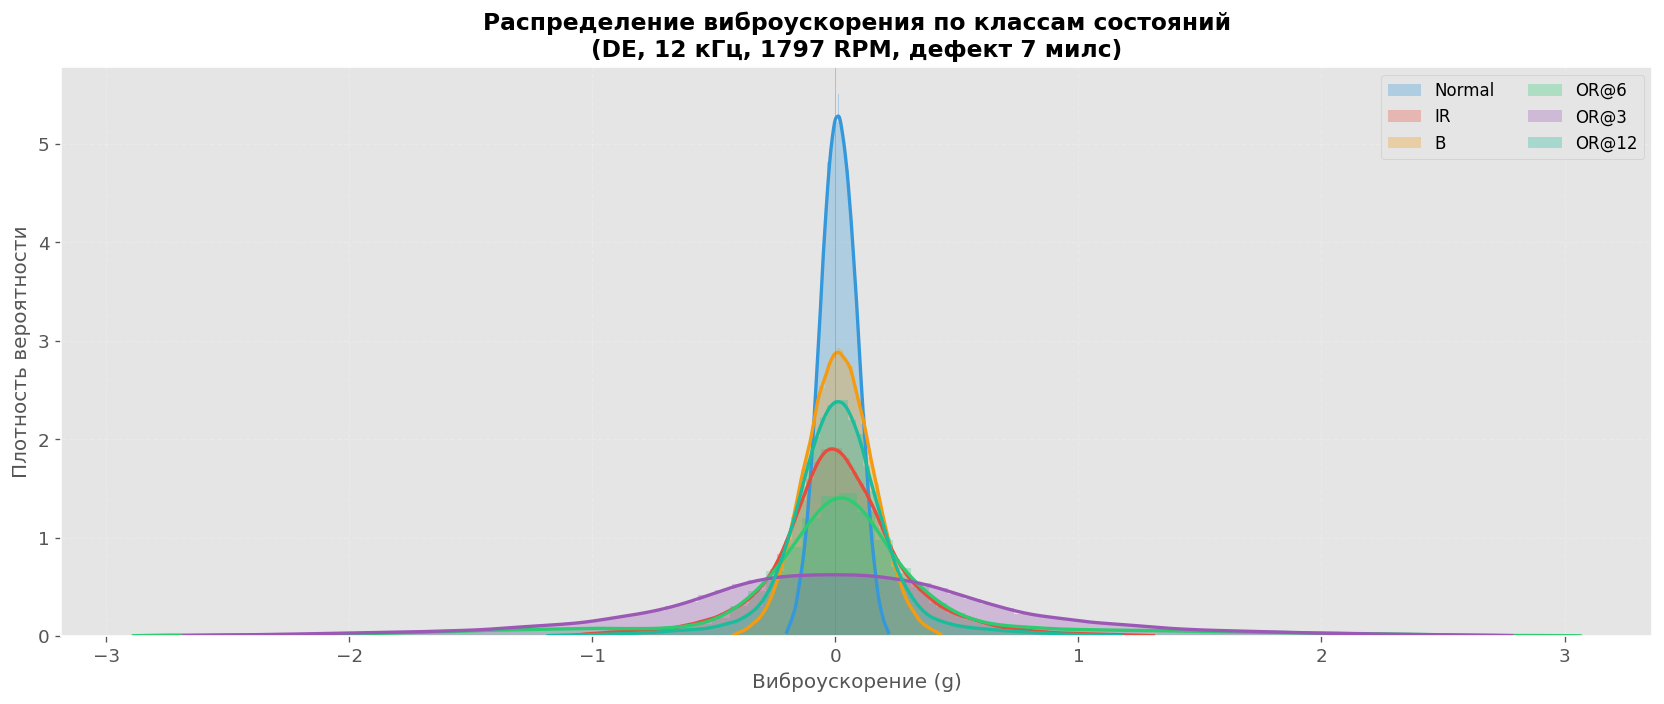


ВЫВОДЫ ПО ЭТАПУ 3–4

1. Распределение вибрационных сигналов содержит выбросы,
   характерные для ударных процессов в неисправных подшипниках.

2. Для дефектных состояний наблюдается увеличение разброса значений
   и расширение межквартильного диапазона.

3. Наличие выбросов связано с прохождением дефекта
   через зону контакта элементов подшипника.

4. Выбросы являются не ошибками измерения,
   а важными диагностическими признаками неисправностей.

5. Данные пригодны для дальнейшего анализа,
   однако перед обучением модели рекомендуется выполнить нормализацию.



In [16]:
# 4.3. Сравнение распределений значений всех классов
# (DE, 1797 RPM, диаметр 7 милс)


signals_dict = {}
for label, fname in stats_specs.items():
    fp = data_root / '1797 RPM' / fname
    if fp.exists():
        signals_dict[label] = np.load(fp)['DE'].flatten()

# Цвета
colors = {
    'Normal': '#3498db',
    'IR': '#e74c3c',
    'B': '#f39c12',
    'OR@6': '#2ecc71',
    'OR@3': '#9b59b6',
    'OR@12': '#1abc9c',
}

fig, ax = plt.subplots(figsize=(14, 6))

for label, sig in signals_dict.items():
    lo, hi = np.quantile(sig, 0.001), np.quantile(sig, 0.999)
    sig_trim = sig[(sig >= lo) & (sig <= hi)]

    # Гистограмма с прозрачностью
    ax.hist(
        sig_trim,
        bins=80,
        density=True,
        alpha=0.3,
        color=colors[label],
        label=label,
        edgecolor='none'
    )

    # KDE линия
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(sig_trim)
    x_kde = np.linspace(lo, hi, 300)
    ax.plot(x_kde, kde(x_kde), color=colors[label], linewidth=2)

ax.set_title(
    'Распределение виброускорения по классам состояний\n'
    '(DE, 12 кГц, 1797 RPM, дефект 7 милс)',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Виброускорение (g)', fontsize=12)
ax.set_ylabel('Плотность вероятности', fontsize=12)
ax.legend(fontsize=10, loc='upper right', ncol=2)
ax.grid(True, alpha=0.2, linestyle='--')
ax.axvline(x=0, color='gray', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('/content/distribution_all_classes.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("""
ВЫВОДЫ ПО ЭТАПУ 3–4

1. Распределение вибрационных сигналов содержит выбросы,
   характерные для ударных процессов в неисправных подшипниках.

2. Для дефектных состояний наблюдается увеличение разброса значений
   и расширение межквартильного диапазона.

3. Наличие выбросов связано с прохождением дефекта
   через зону контакта элементов подшипника.

4. Выбросы являются не ошибками измерения,
   а важными диагностическими признаками неисправностей.

5. Данные пригодны для дальнейшего анализа,
   однако перед обучением модели рекомендуется выполнить нормализацию.
""")

2.3.5. Анализ диапазонов значений

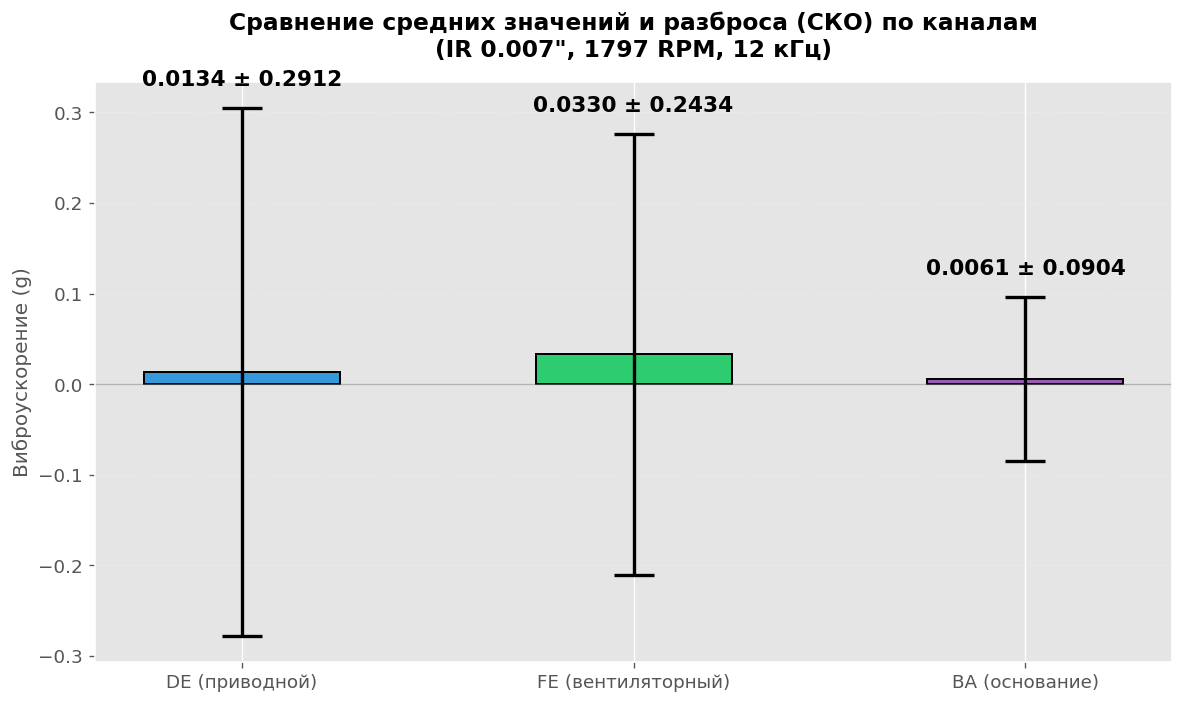

=== СРАВНЕНИЕ КАНАЛОВ (IR 0.007) ===
DE (приводной):
  Среднее = 0.0134, СКО = 0.2912
  Размах = [-1.3799, 1.7390] (ширина = 3.1189)

FE (вентиляторный):
  Среднее = 0.0330, СКО = 0.2434
  Размах = [-1.1397, 0.9632] (ширина = 2.1028)

BA (основание):
  Среднее = 0.0061, СКО = 0.0904
  Размах = [-0.3491, 0.3720] (ширина = 0.7211)



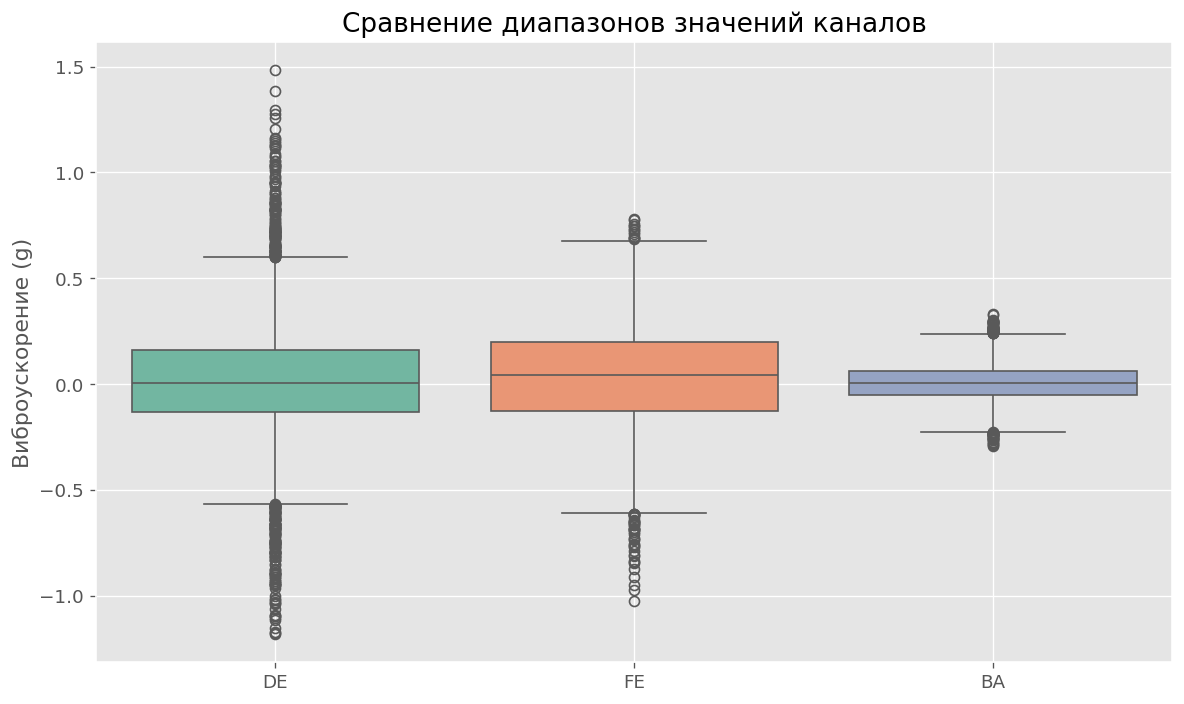


ВЫВОДЫ ПО ЭТАПУ 5

1. Каналы измерений имеют различные диапазоны значений.

2. Канал DE демонстрирует наиболее выраженные колебания.

3. Различие масштабов сигналов показывает необходимость
   нормализации данных перед обучением модели.

4. Использование нескольких каналов позволяет
   повысить информативность диагностики.



In [17]:
# ЭТАП 5: АНАЛИЗ ДИАПАЗОНОВ ЗНАЧЕНИЙ

# 5.1. Сравнение каналов (DE, FE, BA) на примере IR 0.007"
# Простой наглядный график: среднее ± СКО (планки погрешностей)

channels_data = {
    'DE (приводной)': data_fault['DE'],
    'FE (вентиляторный)': data_fault['FE'],
    'BA (основание)': data_fault['BA'],
}

# Считаем статистики
ch_names = []
ch_means = []
ch_stds = []
ch_mins = []
ch_maxs = []

for name, sig in channels_data.items():
    ch_names.append(name)
    ch_means.append(np.mean(sig))
    ch_stds.append(np.std(sig))
    ch_mins.append(np.min(sig))
    ch_maxs.append(np.max(sig))

# Строим столбчатую диаграмму средних с планками СКО
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(ch_names, ch_means, color=['#3498db', '#2ecc71', '#9b59b6'],
              edgecolor='black', linewidth=1.2, width=0.5)

# Добавляем планки погрешностей (±1 СКО)
ax.errorbar(ch_names, ch_means, yerr=ch_stds, fmt='none',
            ecolor='black', capsize=12, capthick=2, linewidth=2, zorder=3)

# Подписываем значения над столбцами
for i, (mean, std) in enumerate(zip(ch_means, ch_stds)):
    ax.text(i, mean + std + 0.02, f'{mean:.4f} ± {std:.4f}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_title('Сравнение средних значений и разброса (СКО) по каналам\n'
             '(IR 0.007", 1797 RPM, 12 кГц)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Виброускорение (g)', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.2, axis='y', linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('/content/channels_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

# Выводим сводку
print("=== СРАВНЕНИЕ КАНАЛОВ (IR 0.007) ===")
for name, mean, std, mn, mx in zip(ch_names, ch_means, ch_stds, ch_mins, ch_maxs):
    print(f"{name}:")
    print(f"  Среднее = {mean:.4f}, СКО = {std:.4f}")
    print(f"  Размах = [{mn:.4f}, {mx:.4f}] (ширина = {mx-mn:.4f})")
    print()

#общая диаграмма размаха каналов

df_channels_box = pd.DataFrame({
    'DE': data_fault['DE'][:5000],
    'FE': data_fault['FE'][:5000],
    'BA': data_fault['BA'][:5000]
})

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_channels_box)

plt.title('Сравнение диапазонов значений каналов')
plt.ylabel('Виброускорение (g)')

plt.grid(True)

plt.tight_layout()

plt.show()

print("""
ВЫВОДЫ ПО ЭТАПУ 5

1. Каналы измерений имеют различные диапазоны значений.

2. Канал DE демонстрирует наиболее выраженные колебания.

3. Различие масштабов сигналов показывает необходимость
   нормализации данных перед обучением модели.

4. Использование нескольких каналов позволяет
   повысить информативность диагностики.
""")

Матрица корреляции каналов (IR 0.007", 1797 RPM):
          DE        FE        BA
DE  1.000000 -0.008507 -0.057355
FE -0.008507  1.000000 -0.432353
BA -0.057355 -0.432353  1.000000


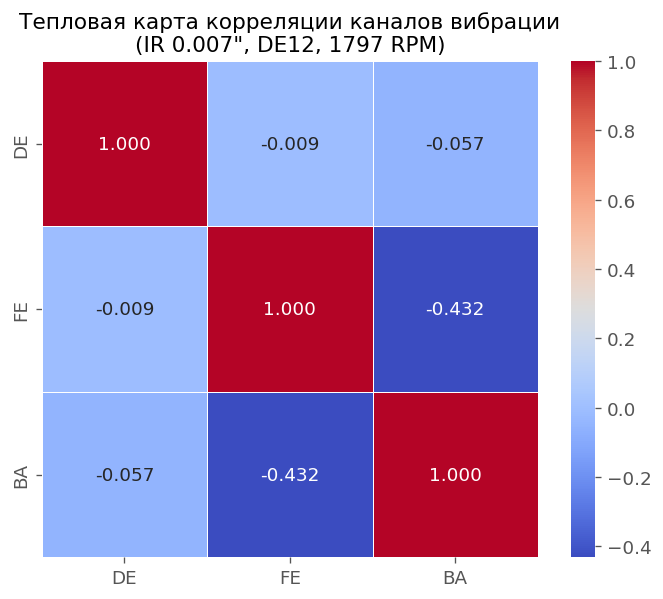


ВЫВОДЫ ПО ЭТАПУ 6
1. Диапазоны значений каналов различаются,
   что указывает на различную чувствительность датчиков.

2. Канал DE демонстрирует наиболее выраженные колебания
   и содержит наиболее информативные диагностические признаки.

3. Различие масштабов сигналов показывает необходимость
   применения нормализации или стандартизации перед обучением модели.

4. Использование нескольких каналов позволяет учитывать
   пространственные особенности распространения вибраций.



In [18]:
# 6.1. Подготовка многомерного набора для одного состояния
# Используем сигнал IR 0.007", 1797 RPM, DE12 (переменная data_fault)
df_corr = pd.DataFrame({
    'DE': data_fault['DE'],
    'FE': data_fault['FE'],
    'BA': data_fault['BA']
})

# 6.2. Расчёт матрицы парных коэффициентов корреляции Пирсона
corr_matrix = df_corr.corr()
print("Матрица корреляции каналов (IR 0.007\", 1797 RPM):")
print(corr_matrix)

# 6.3. Тепловая карта корреляций
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Тепловая карта корреляции каналов вибрации\n(IR 0.007", DE12, 1797 RPM)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
ВЫВОДЫ ПО ЭТАПУ 6
1. Диапазоны значений каналов различаются,
   что указывает на различную чувствительность датчиков.

2. Канал DE демонстрирует наиболее выраженные колебания
   и содержит наиболее информативные диагностические признаки.

3. Различие масштабов сигналов показывает необходимость
   применения нормализации или стандартизации перед обучением модели.

4. Использование нескольких каналов позволяет учитывать
   пространственные особенности распространения вибраций.
""")

SNR = -20.7 дБ
Дисперсия сигнала: 0.000715, дисперсия шума: 0.084012


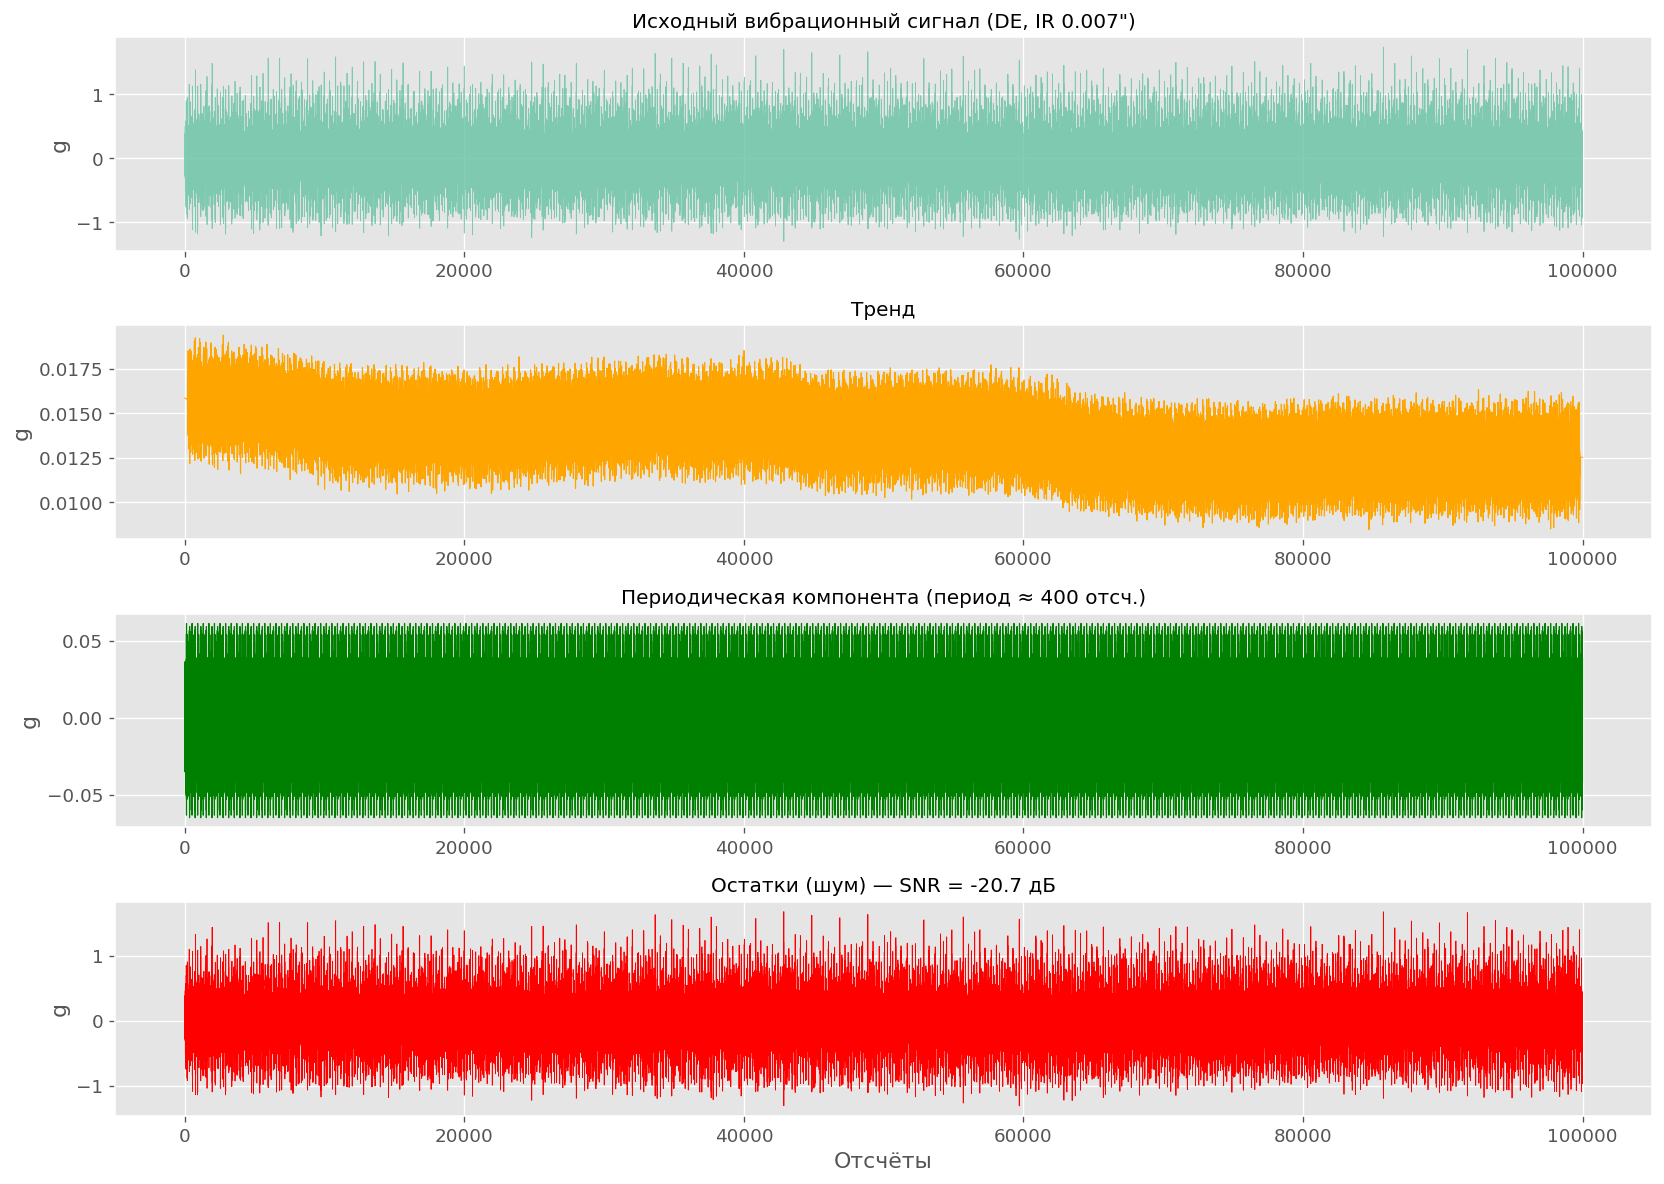

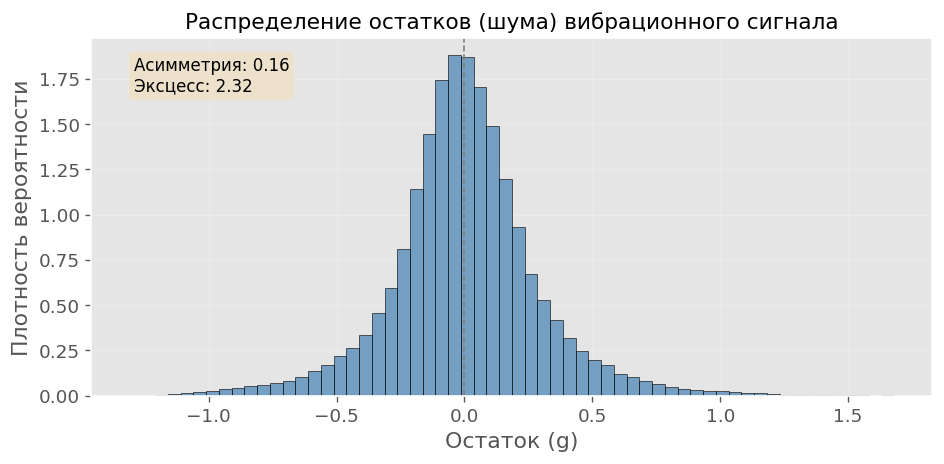

Характеристики остатков:
  Асимметрия = 0.165
  Эксцесс    = 2.315

ВЫВОДЫ ПО ЭТАПУ 7

1. Выполнена декомпозиция вибрационного сигнала
   на тренд, периодическую и шумовую составляющие.

2. Периодическая компонента отражает циклический характер
   работы подшипника и вращения вала.

3. Значение отношения сигнал/шум определяется переменной snr
   и характеризует уровень шумовой составляющей сигнала.

4. Остаточная компонента после декомпозиции
   имеет преимущественно случайный характер.

5. Значения асимметрии и эксцесса,
   вычисленные через skew(residual) и kurtosis(residual),
   позволяют оценить форму распределения шумов.

6. Уровень шумов является допустимым
   для дальнейшего анализа и машинного обучения.



In [19]:
# ЭТАП 7: ПОИСК И АНАЛИЗ ШУМОВ

from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import skew, kurtosis

# 7.1. Выбор сигнала и обрезка до 100 000 отсчётов
sig = data_fault['DE'][:100000]          # канал DE, IR 0.007"

# 7.2. Период, соответствующий частоте вращения вала (~30 Гц → 400 отсчётов)
period = 400

# 7.3. Декомпозиция (аддитивная модель)
decomp = seasonal_decompose(sig, model='additive', period=period, extrapolate_trend='freq')
trend = decomp.trend
seasonal = decomp.seasonal
# Безопасное удаление NaN (работает и с ndarray, и с Series)
residual = decomp.resid
residual = residual[~np.isnan(residual)]

# 7.4. Сигнал = тренд + сезонность (выровненная длина)
trend_clean = trend[~np.isnan(trend)]
seasonal_clean = seasonal[~np.isnan(seasonal)][:len(trend_clean)]
signal_comp = trend_clean + seasonal_clean

noise_var = np.var(residual)
signal_var = np.var(signal_comp)
snr = 10 * np.log10(signal_var / noise_var) if noise_var > 0 else float('inf')

print(f"SNR = {snr:.1f} дБ")
print(f"Дисперсия сигнала: {signal_var:.6f}, дисперсия шума: {noise_var:.6f}")

# 7.5. Визуализация компонент
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(sig, linewidth=0.5, alpha=0.8)
axes[0].set_title('Исходный вибрационный сигнал (DE, IR 0.007")', fontsize=12)
axes[0].set_ylabel('g')

axes[1].plot(trend, linewidth=0.7, color='orange')
axes[1].set_title('Тренд', fontsize=12)
axes[1].set_ylabel('g')

axes[2].plot(seasonal, linewidth=0.7, color='green')
axes[2].set_title('Периодическая компонента (период ≈ 400 отсч.)', fontsize=12)
axes[2].set_ylabel('g')

axes[3].plot(residual, linewidth=0.5, color='red')
axes[3].set_title(f'Остатки (шум) — SNR = {snr:.1f} дБ', fontsize=12)
axes[3].set_xlabel('Отсчёты')
axes[3].set_ylabel('g')

plt.tight_layout()
plt.savefig('/content/decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# 7.6. Гистограмма распределения остатков
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residual, bins=60, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Распределение остатков (шума) вибрационного сигнала', fontsize=13)
ax.set_xlabel('Остаток (g)')
ax.set_ylabel('Плотность вероятности')
ax.grid(True, alpha=0.2)

textstr = f'Асимметрия: {skew(residual):.2f}\nЭксцесс: {kurtosis(residual):.2f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('/content/residual_hist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Характеристики остатков:\n"
      f"  Асимметрия = {skew(residual):.3f}\n"
      f"  Эксцесс    = {kurtosis(residual):.3f}")

print(f"""
ВЫВОДЫ ПО ЭТАПУ 7

1. Выполнена декомпозиция вибрационного сигнала
   на тренд, периодическую и шумовую составляющие.

2. Периодическая компонента отражает циклический характер
   работы подшипника и вращения вала.

3. Значение отношения сигнал/шум определяется переменной snr
   и характеризует уровень шумовой составляющей сигнала.

4. Остаточная компонента после декомпозиции
   имеет преимущественно случайный характер.

5. Значения асимметрии и эксцесса,
   вычисленные через skew(residual) и kurtosis(residual),
   позволяют оценить форму распределения шумов.

6. Уровень шумов является допустимым
   для дальнейшего анализа и машинного обучения.
""")